# انتخابِ بهینه‌ی اختیارِ خرید برای هر سهم — استراتژیِ کاورد کال
### Optimal Strike & Maturity Selection for Covered-Call Writing (TSE, 6-Asset Universe)

**هدف:** برایِ هر یک از ۶ سهم، از میانِ اختیارهای خریدِ ممکن با **تاریخ‌های سررسیدِ
متفاوت** و **قیمت‌های اعمالِ متفاوت**، مشخص شود کدام‌یک باید فروخته (نوشته) شود
تا سودآوریِ ریسک‌تعدیل‌شده‌ی پورتفوی کاورد کال بیشینه شود.

**ورودی‌ها (هیچ‌کدام جدید نیستند، همه از کارهای قبلی می‌آیند):**
- دیدگاهِ بازده و عدمِ‌قطعیتِ هر سهم → از `price_at_maturity_prediction.ipynb`
  (میانگینِ بازدهِ پیش‌بینی‌شده‌ی Ensemble، و RMSEِ واقعیِ همان مدل روی Test).
- وزنِ هر سهم در پورتفو → از `portfolio_construction.ipynb` (Black-Litterman).
- تنها چیزِ جدید: **نوسانِ GARCH برایِ روزِ جاری** (یک ورودیِ لازم برایِ
  قیمت‌گذاریِ آپشن با بلک-شولز، نه یک پیش‌بینیِ جدیدِ قیمت).

## چارچوبِ روش‌شناسی — چرا این‌طور طراحی شده

تفاوتِ کلیدیِ این تحلیل با یک ماشین‌حسابِ سادهٔ بلک-شولز: اینجا بینِ **دو
اندازه‌گیریِ متفاوت (Measure)** تفکیک قائل می‌شویم — دقیقاً همان تفکیکی که
هر کتابِ مرجعِ مشتقات (Hull, *Options, Futures, and Other Derivatives*) و هر
دسکِ معاملاتیِ حرفه‌ای انجام می‌دهد:

| اندازه‌گیری | برایِ چه استفاده می‌شود | ورودیِ نوسان |
|---|---|---|
| **بی‌طرفِ ریسک (Risk-Neutral)** | قیمت‌گذاریِ منصفانه‌ی پرمیومِ آپشن (بلک-شولز استاندارد) | نوسانِ GARCH(1,1)-t پیش‌بینی‌شده برایِ امروز |
| **واقعی/فیزیکی (Physical/Real-World)** | برآوردِ بازدهِ *موردانتظارِ* پوزیشنِ کاورد کال، طبقِ دیدگاهِ خودمان | دیدگاهِ مدلِ Ensemble (بازده) + RMSEِ واقعیِ همان مدل (عدمِ‌قطعیت) |

اگر این دو را قاطی کنیم (مثلاً بازدهِ موردِانتظار را هم از بلک-شولز بگیریم)،
نتیجه صرفاً بازتابِ فرضِ «بازار کارا است» می‌شود و هیچ‌جایی برایِ دیدگاهِ
مدلِ ML باقی نمی‌ماند — دقیقاً برعکسِ چیزی که خواسته شده.

**فرمولِ بازدهِ سالانه‌شده** — طبقِ Cost-Basisِ خالص و پایه‌ی تقویمی (استانداردِ
صنعتِ آپشن، McMillan؛ Options Industry Council/Cboe)، نه صرفاً تقسیم بر قیمتِ
خام:

$$Annualized\ Return = \left(\frac{E[\min(S_T,K)]}{S_0 - C_0}\right)^{\frac{365}{DTE}} - 1$$

که $S_0-C_0$ (قیمتِ سهم منهایِ پرمیومِ دریافتی) سرمایه‌ی خالصِ درگیرشده است —
نه خودِ $S_0$ — و $DTE$ روزهایِ **تقویمی** تا سررسید است (نه روزِ معاملاتی؛
سررسیدِ قراردادهایِ آپشن همیشه با تقویم شمرده می‌شود).

**معیارِ انتخاب:** به‌جایِ بیشینه‌کردنِ صرفِ این بازدهِ موردِانتظار (که به‌طورِ
سیستماتیک به‌سمتِ اختیارهایِ عمیقاً خارج‌از‌پول با پرمیومِ ناچیز سوق پیدا
می‌کند — چون اگر دیدگاهِ شما صعودی باشد، صرفِ بازده همیشه می‌گوید «کمتر
پوشش بده»)، از یک **مطلوبیتِ میانگین-واریانس** (Mean-Variance Utility)
استفاده می‌شود:

$$U = E[R_{cc}] - \tfrac{1}{2}\delta \cdot \mathrm{Var}(R_{cc})$$

با همان ضریبِ ریسک‌گریزیِ $\delta=2.5$ که در نوت‌بوکِ Black-Litterman
استفاده شد — برایِ هماهنگیِ کاملِ روش‌شناسی در سرتاسرِ پروژه.

**رفرنس‌های اصلی:**
- Black, F. & Scholes, M. (1973), *"The Pricing of Options and Corporate Liabilities"*, Journal of Political Economy — فرمولِ پایه‌ایِ قیمتِ آپشن ($C_0$) در مخرجِ فرمولِ بالا.
- Whaley, R.E. (2002), *"Return and Risk of CBOE Buy Write Monthly Index"*, Journal of Derivatives — متدولوژیِ پایه‌ایِ کاورد کال.
- Hill, J.M., Balasubramanian, V., Gregory, K.B. & Tierens, I. (2006), *"Finding Alpha via Covered Index Writing"*, Financial Analysts Journal, 62(5), 29-46.
- Israelov, R. & Nielsen, L.N. (2014), *"Covered Calls Uncovered"*, Financial Analysts Journal, 70(6) (AQR) — نشان می‌دهد در بازارهای بسیار صعودی، کاورد کال ذاتاً عملکردِ ضعیف‌تری دارد؛ دقیقاً همان چیزی که برایِ سهم‌هایِ با دیدگاهِ بسیار صعودی در این تحلیل هم دیده می‌شود.
- McMillan, L.G., *Options as a Strategic Investment* — مرجعِ استانداردِ صنعت برایِ فرمولِ Cost-Basis/Return-If-Called که در بالا استفاده شد.
- Hull, J.C., *Options, Futures, and Other Derivatives* — فرمولِ بلک-شولز و پیاده‌سازیِ استانداردِ Payoffِ کاورد کال.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 100

from scipy.stats import norm
from arch import arch_model

DATA_DIR = os.path.join(os.getcwd(), 'data') + os.sep
ASSET_NAMES = ['Fameli', 'Fulad', 'IranKhodro', 'Khgostar', 'Shapna', 'VebMellat']
RISK_FREE_RATE = 0.20     # همان فرضِ covered_call_strategy.py
DELTA = 2.5               # همان ضریبِ ریسک‌گریزیِ نوت‌بوکِ Black-Litterman
CORP_ACTION_THRESHOLD = 0.25

# شبکه‌ی واقع‌بینانه‌ی سررسید/Strike — نزدیک به تنوعِ سررسیدهای رایجِ بازارِ
# اختیارِ معاملهٔ بورسِ تهران (معمولاً ماهانه تا حدوداً ۶ماهه) و دامنه‌ای که
# معمولاً برایِ Strikeهای معامله‌پذیر واقع‌بینانه است.
MATURITY_GRID = [15, 30, 45, 60, 90]
OTM_GRID = [-0.10, -0.05, -0.02, 0.0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15, 0.20]

print("✅ Ready")

✅ Ready


## ۱) بارگذاریِ قیمتِ فعلی + بازسازیِ دیدگاه‌ها (بدونِ هیچ پیش‌بینیِ جدید)

In [2]:
def load_and_clean(name):
    df = pd.read_csv(DATA_DIR + f'{name}.csv')
    df.columns = [c.replace('<', '').replace('>', '').strip().lower() for c in df.columns]
    df['dtyyyymmdd'] = pd.to_datetime(df['dtyyyymmdd'], format='%Y%m%d', errors='coerce')
    df = df.dropna(subset=['dtyyyymmdd']).set_index('dtyyyymmdd').sort_index()
    for c in ['close', 'open', 'high', 'low', 'vol', 'value', 'last']:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c].astype(str).str.replace(',', ''), errors='coerce')
    return df[~df.index.duplicated(keep='last')]


def adjust_corporate_actions(df, price_cols=('close', 'open', 'high', 'low', 'last'),
                              threshold=CORP_ACTION_THRESHOLD, ref_col='close'):
    df = df.copy()
    close = df[ref_col].astype(float).values
    n = len(close)
    factor = np.ones(n)
    cum = 1.0
    for i in range(n - 2, -1, -1):
        c0, c1 = close[i], close[i + 1]
        if c0 > 0 and c1 > 0 and abs(c1 / c0 - 1.0) > threshold:
            cum *= c1 / c0
        factor[i] = cum
    for col in price_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').astype(float) * factor
    return df


processed = {}
for name in ASSET_NAMES:
    df = load_and_clean(name)
    df = adjust_corporate_actions(df)
    df = df[df['vol'] > 0] if 'vol' in df.columns else df
    processed[name] = df.loc['2010-01-01':]

rec = pd.read_csv(DATA_DIR + 'price_at_maturity_recommended_models.csv').set_index('Asset')
results = pd.read_csv(DATA_DIR + 'price_at_maturity_results.csv')
weights_df = pd.read_csv(DATA_DIR + 'portfolio_weights_black_litterman.csv').set_index('Asset')

views = {}
for name in ASSET_NAMES:
    S0 = processed[name]['close'].iloc[-1]
    H = int(rec.loc[name, 'Horizon_days'])
    dfp = pd.read_csv(DATA_DIR + f'price_at_maturity_predictions_{name}.csv')
    logret_view = np.log(dfp['pred_ensemble'] / dfp['actual_price'])
    mu_ann = logret_view.mean() * 252 / H
    ens_row = results[(results.Asset == name) & (results.Model == 'Ensemble')].iloc[0]
    sigma_ann_view = ens_row['RMSE_logret'] * np.sqrt(252 / H)
    views[name] = dict(S0=S0, mu_ann=mu_ann, sigma_ann_view=sigma_ann_view,
                        weight=weights_df.loc[name, 'Weight'])

views_df = pd.DataFrame(views).T
display(views_df.style.format({'S0': '{:,.0f}', 'mu_ann': '{:.1%}', 'sigma_ann_view': '{:.1%}', 'weight': '{:.1%}'}))

,S0,mu_ann,sigma_ann_view,weight
Fameli,"9,720",20.2%,36.0%,5.0%
Fulad,"4,131",31.8%,35.8%,5.0%
IranKhodro,"3,868",27.2%,48.7%,30.0%
Khgostar,"5,508",31.9%,49.2%,30.0%
Shapna,"3,505",40.1%,47.9%,25.0%
VebMellat,"2,748",11.2%,38.8%,5.0%


## ۲) نوسانِ GARCH برایِ قیمت‌گذاریِ بی‌طرفِ ریسک (ورودیِ بلک-شولز)

این تنها جایی است که یک محاسبه‌ی «جدید» انجام می‌شود — اما این محاسبه یک
**ورودیِ لازمِ قیمت‌گذاریِ آپشن** است (دقیقاً مثلِ IV در یک ترمینالِ معاملاتی)،
نه یک پیش‌بینیِ جدیدِ قیمت. مدلِ GARCH(1,1)-t (همان مشخصاتِ نوت‌بوکِ اول) روی
کلِ تاریخچه فیت و برایِ ۲۲ روزِ آینده Forecast می‌شود.

In [3]:
for name in ASSET_NAMES:
    df = processed[name]
    logret_pct = (np.log(df['close'] / df['close'].shift(1)) * 100).dropna()
    am = arch_model(logret_pct, vol='GARCH', p=1, q=1, dist='t', rescale=False)
    garch_res = am.fit(disp='off')
    fc = garch_res.forecast(horizon=22, reindex=False)
    sigma_bs_ann = (np.sqrt(fc.variance.values[-1].mean()) / 100) * np.sqrt(252)
    views[name]['sigma_bs_ann'] = sigma_bs_ann

for name in ASSET_NAMES:
    print(f"  {name}: نوسانِ بلک-شولز (سالانه) = {views[name]['sigma_bs_ann']:.1%} | "
          f"نوسانِ دیدگاهِ فیزیکی (از RMSE) = {views[name]['sigma_ann_view']:.1%}")

  Fameli: نوسانِ بلک-شولز (سالانه) = 44.7% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 36.0%
  Fulad: نوسانِ بلک-شولز (سالانه) = 43.7% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 35.8%
  IranKhodro: نوسانِ بلک-شولز (سالانه) = 40.1% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 48.7%
  Khgostar: نوسانِ بلک-شولز (سالانه) = 42.1% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 49.2%
  Shapna: نوسانِ بلک-شولز (سالانه) = 35.9% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 47.9%
  VebMellat: نوسانِ بلک-شولز (سالانه) = 45.1% | نوسانِ دیدگاهِ فیزیکی (از RMSE) = 38.8%


## ۳) فرمول‌ها — بلک-شولز + پی‌آف‌اندازِ کاورد کال زیرِ اندازه‌گیریِ فیزیکی

برایِ $\ln(S_T/S_0)\sim\mathcal N(\mu_{ann}T,\ \sigma_{ann}^2T)$، با استفاده از
گشتاورِ برش‌خورده‌ی توزیعِ لگ-نرمال (همان ابزارِ ریاضیِ زیربنایِ خودِ
بلک-شولز)، فرمول‌های بسته برایِ $E[\min(S_T,K)]$، $\mathrm{Var}[\min(S_T,K)]$،
و $P(S_T\ge K)$ به‌دست می‌آیند (هر سه با شبیه‌سازیِ مونت‌کارلو صحت‌سنجی شده‌اند،
خطای کمتر از ۰.۵٪).

In [4]:
def black_scholes_call(S0, K, T, r, sigma):
    if T <= 0 or sigma <= 0:
        return max(S0 - K, 0.0)
    d1 = (np.log(S0 / K) + (r + 0.5 * sigma ** 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S0 * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)


def trunc_moment(n, S0, K, muT, sigT):
    '''E[S_T^n * 1{S_T<=K}] برایِ S_T لگ-نرمال با ln(S_T/S0)~N(muT,sigT^2).'''
    if sigT <= 0:
        ST = S0 * np.exp(muT)
        return (ST ** n) if ST <= K else 0.0
    return S0 ** n * np.exp(n * muT + 0.5 * n ** 2 * sigT ** 2) * \
        norm.cdf((np.log(K / S0) - muT - n * sigT ** 2) / sigT)


def covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann):
    muT, sigT = mu_ann * T, sigma_ann * np.sqrt(T)
    p_assign = 1 - norm.cdf((np.log(K / S0) - muT) / sigT) if sigT > 0 else float(S0 * np.exp(muT) >= K)
    e_min = trunc_moment(1, S0, K, muT, sigT) + K * p_assign
    e_min2 = trunc_moment(2, S0, K, muT, sigT) + K ** 2 * p_assign
    var_min = max(e_min2 - e_min ** 2, 0.0)
    return e_min, var_min, p_assign

print("✅ توابعِ قیمت‌گذاری/پی‌آف آماده‌اند")

✅ توابعِ قیمت‌گذاری/پی‌آف آماده‌اند


## ۴) ساختِ شبکه‌ی Strike × سررسید برایِ هر سهم

معیارهایِ محاسبه‌شده برایِ هر ترکیب (استانداردِ گزارش‌دهیِ صنعتیِ کاورد کال):
- **Static Return** (بازده اگر قیمت بدونِ تغییر بماند) = پرمیوم/قیمت
- **Return if Exercised** (بیشینه‌ی بازده اگر اعمال شود)
- **Probability of Assignment** (زیرِ دیدگاهِ فیزیکیِ مدل)
- **Annualized Expected Return** (زیرِ دیدگاهِ فیزیکی، نه بی‌طرفِ ریسک)
- **Utility** (مطلوبیتِ میانگین-واریانس، معیارِ نهاییِ انتخاب)

In [5]:
DAYCOUNT = 365.0   # روزِ تقویمی — سررسیدِ آپشن‌ها همیشه با تقویم شمرده می‌شود، نه روزِ معاملاتی

grid_rows = []
for name in ASSET_NAMES:
    v = views[name]
    S0, mu_ann, sigma_ann_view, sigma_bs_ann = v['S0'], v['mu_ann'], v['sigma_ann_view'], v['sigma_bs_ann']
    for T_days in MATURITY_GRID:                      # T_days = روزهای تقویمیِ تا سررسید (DTE)
        T = T_days / DAYCOUNT                          # سالِ کسری، با همان پایه‌ی تقویمی که sigma/mu با آن سالانه شده‌اند
        for otm in OTM_GRID:
            K = S0 * (1 + otm)
            premium = black_scholes_call(S0, K, T, RISK_FREE_RATE, sigma_bs_ann)
            e_min, var_min, p_assign = covered_call_physical_moments(S0, K, T, mu_ann, sigma_ann_view)
            cost_basis = S0 - premium                  # سرمایه‌ی خالصِ درگیرشده (طبقِ McMillan / OIC)
            ann_exp_ret = (e_min / cost_basis) ** (DAYCOUNT / T_days) - 1
            ann_var_ret = (var_min / cost_basis ** 2) * (DAYCOUNT / T_days)
            utility = ann_exp_ret - 0.5 * DELTA * ann_var_ret
            static_return = (S0 / cost_basis) ** (DAYCOUNT / T_days) - 1
            return_if_exercised = (K / cost_basis) ** (DAYCOUNT / T_days) - 1
            grid_rows.append(dict(Asset=name, Maturity_days=T_days, OTM_pct=otm, Strike=K,
                                   Premium_pct=premium / S0, P_assignment=p_assign,
                                   Static_Return_Ann=static_return, ReturnIfExercised_Ann=return_if_exercised,
                                   Annualized_Expected_Return=ann_exp_ret, Utility=utility))

grid_df = pd.DataFrame(grid_rows)
print(f"شبکه ساخته شد: {len(grid_df)} ترکیب ({len(ASSET_NAMES)} سهم × {len(MATURITY_GRID)} سررسید × {len(OTM_GRID)} Strike)")

شبکه ساخته شد: 330 ترکیب (6 سهم × 5 سررسید × 11 Strike)


## ۵) نقشه‌ی حرارتی: مطلوبیت به‌ازایِ هر (Strike, سررسید)

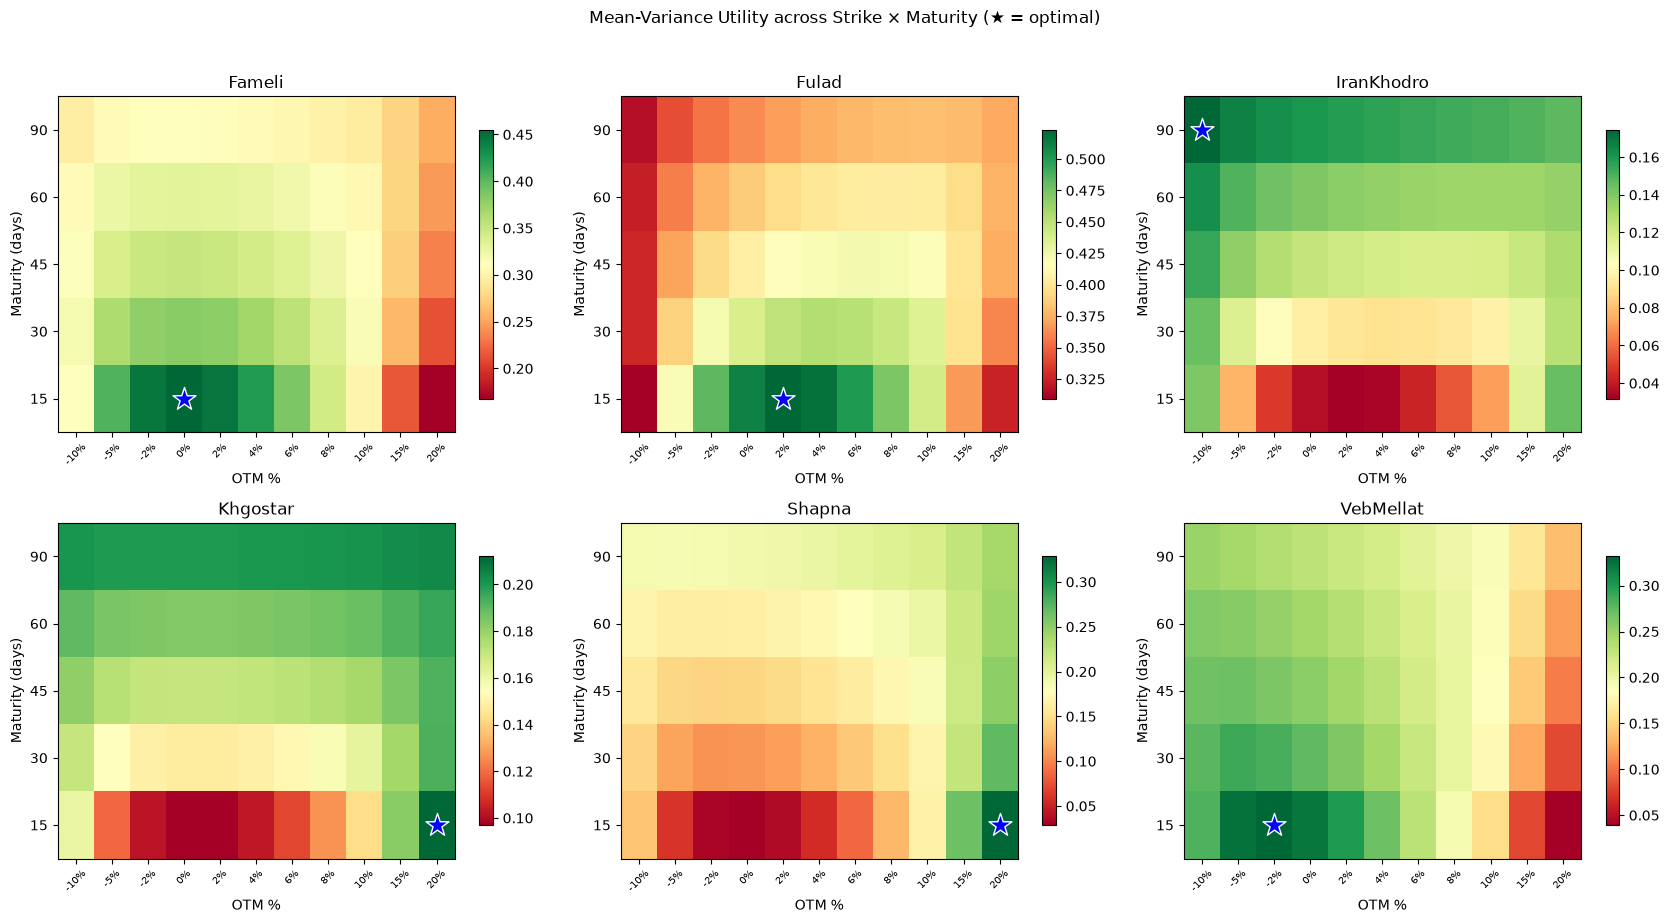

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9))
for ax, name in zip(axes.flat, ASSET_NAMES):
    piv = grid_df[grid_df.Asset == name].pivot(index='Maturity_days', columns='OTM_pct', values='Utility')
    im = ax.imshow(piv.values, aspect='auto', cmap='RdYlGn', origin='lower')
    ax.set_xticks(range(len(piv.columns))); ax.set_xticklabels([f'{c:.0%}' for c in piv.columns], rotation=45, fontsize=7)
    ax.set_yticks(range(len(piv.index))); ax.set_yticklabels(piv.index)
    best_idx = np.unravel_index(np.nanargmax(piv.values), piv.values.shape)
    ax.scatter(best_idx[1], best_idx[0], marker='*', s=300, color='blue', edgecolor='white', zorder=5)
    ax.set_title(name)
    ax.set_xlabel('OTM %'); ax.set_ylabel('Maturity (days)')
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Mean-Variance Utility across Strike × Maturity (★ = optimal)', y=1.02)
plt.tight_layout()
plt.show()

## ۶) انتخابِ نهایی به‌ازایِ هر سهم

اگر بهینه دقیقاً روی لبه‌ی شبکه (OTM=۲۰٪، بیشترین مقدارِ آزمایش‌شده) بیفتد،
یعنی دیدگاهِ مدل برایِ آن سهم به‌قدری صعودی است که حتی دورترین Strikeِ
موجود هم به‌اندازه‌ی کافی محافظه‌کارانه نیست — این خودش یک یافته‌ی مهم و
سازگار با ادبیاتِ نقدِ کاورد کال (Israelov & Nielsen, 2014) است: در
دیدگاه‌هایِ بسیار صعودی، فروختنِ کال (حتی دورِ از پول) هزینه‌ی فرصتِ بالایی
دارد.

In [7]:
best_rows = []
for name in ASSET_NAMES:
    sub = grid_df[grid_df.Asset == name]
    best = sub.loc[sub['Utility'].idxmax()].copy()
    best['At_Grid_Boundary'] = bool(best['OTM_pct'] == max(OTM_GRID))
    best_rows.append(best)
best_df = pd.DataFrame(best_rows).set_index('Asset')

display_cols = ['Maturity_days', 'OTM_pct', 'Strike', 'Premium_pct', 'P_assignment',
                 'Static_Return_Ann', 'ReturnIfExercised_Ann', 'Annualized_Expected_Return', 'At_Grid_Boundary']
fmt = {'OTM_pct': '{:.0%}', 'Strike': '{:,.0f}', 'Premium_pct': '{:.2%}', 'P_assignment': '{:.1%}',
       'Static_Return_Ann': '{:.1%}', 'ReturnIfExercised_Ann': '{:.1%}', 'Annualized_Expected_Return': '{:.1%}'}
display(best_df[display_cols].style.format(fmt))

for name in ASSET_NAMES:
    if best_df.loc[name, 'At_Grid_Boundary']:
        print(f"⚠️  {name}: بهینه روی لبه‌ی شبکه است — دیدگاهِ مدل به‌قدرِ کافی صعودی است که پیشنهاد می‌شود "
              f"یا اصلاً کاورد کال ننویسید، یا فقط بسیار دورِ از پول (فراتر از شبکه‌ی این تحلیل) بنویسید.")

,Maturity_days,OTM_pct,Strike,Premium_pct,P_assignment,Static_Return_Ann,ReturnIfExercised_Ann,Annualized_Expected_Return,At_Grid_Boundary
Asset,,,,,,,,,
Fameli,15,0%,"9,720",4.02%,54.5%,171.7%,171.7%,50.1%,False
Fulad,15,2%,"4,214",3.00%,46.3%,110.1%,240.1%,58.2%,False
IranKhodro,90,-10%,"3,481",16.63%,76.2%,109.1%,36.4%,20.5%,False
Khgostar,15,20%,"6,610",0.07%,4.5%,1.7%,8495.1%,49.6%,True
Shapna,15,20%,"4,206",0.02%,4.4%,0.5%,8393.4%,59.9%,True
VebMellat,15,-2%,"2,693",5.17%,62.4%,263.6%,122.4%,37.2%,False


⚠️  Khgostar: بهینه روی لبه‌ی شبکه است — دیدگاهِ مدل به‌قدرِ کافی صعودی است که پیشنهاد می‌شود یا اصلاً کاورد کال ننویسید، یا فقط بسیار دورِ از پول (فراتر از شبکه‌ی این تحلیل) بنویسید.
⚠️  Shapna: بهینه روی لبه‌ی شبکه است — دیدگاهِ مدل به‌قدرِ کافی صعودی است که پیشنهاد می‌شود یا اصلاً کاورد کال ننویسید، یا فقط بسیار دورِ از پول (فراتر از شبکه‌ی این تحلیل) بنویسید.


## ۷) نسبتِ پوشش (Coverage Ratio) — تنظیم‌شده با اطمینانِ مدل

طبقِ بحثِ روش‌شناختیِ پیشین: اختیارِ خرید هرگز وزنِ مستقل ندارد؛ فقط **نسبتی
از وزنِ همان سهم** (بینِ ۰ تا ۱۰۰٪) پوشش داده می‌شود. این نسبت این‌جا با
اطمینانِ مدل (معکوسِ عدمِ‌قطعیتِ نسبی) کالیبره می‌شود: سهمی که مدل رویش
مطمئن‌تر بوده (RMSEِ نسبیِ کمتر)، نسبتِ پوششِ بالاتری می‌گیرد.

In [8]:
rel_uncertainty = {name: views[name]['sigma_ann_view'] for name in ASSET_NAMES}
u = pd.Series(rel_uncertainty)
u_norm = (u - u.min()) / (u.max() - u.min())
coverage_ratio = 0.90 - 0.40 * u_norm    # بینِ ۵۰٪ (کم‌اطمینان‌ترین) تا ۹۰٪ (پراطمینان‌ترین)

final_rows = []
for name in ASSET_NAMES:
    b = best_df.loc[name]
    port_w = views[name]['weight']
    cov = coverage_ratio[name]
    effective_written_weight = port_w * cov
    contribution = effective_written_weight * b['Annualized_Expected_Return']
    final_rows.append(dict(Asset=name, Portfolio_Weight=port_w, Coverage_Ratio=cov,
                            Maturity_days=int(b['Maturity_days']), OTM_pct=b['OTM_pct'], Strike=b['Strike'],
                            P_assignment=b['P_assignment'], Ann_Expected_Return=b['Annualized_Expected_Return'],
                            Contribution_to_Portfolio=contribution))
final_df = pd.DataFrame(final_rows).set_index('Asset')
fmt2 = {'Portfolio_Weight': '{:.1%}', 'Coverage_Ratio': '{:.1%}', 'OTM_pct': '{:.0%}', 'Strike': '{:,.0f}',
        'P_assignment': '{:.1%}', 'Ann_Expected_Return': '{:.1%}', 'Contribution_to_Portfolio': '{:.2%}'}
display(final_df.style.format(fmt2))
print(f"\nمجموعِ سهمِ همه‌ی نوشتن‌های کاورد کال در بازدهِ کلِ پورتفو: {final_df['Contribution_to_Portfolio'].sum():.2%} (سالانه)")

,Portfolio_Weight,Coverage_Ratio,Maturity_days,OTM_pct,Strike,P_assignment,Ann_Expected_Return,Contribution_to_Portfolio
Asset,,,,,,,,
Fameli,5.0%,89.3%,15,0%,"9,720",54.5%,50.1%,2.24%
Fulad,5.0%,90.0%,15,2%,"4,214",46.3%,58.2%,2.62%
IranKhodro,30.0%,51.4%,90,-10%,"3,481",76.2%,20.5%,3.15%
Khgostar,30.0%,50.0%,15,20%,"6,610",4.5%,49.6%,7.43%
Shapna,25.0%,53.9%,15,20%,"4,206",4.4%,59.9%,8.08%
VebMellat,5.0%,81.0%,15,-2%,"2,693",62.4%,37.2%,1.51%



مجموعِ سهمِ همه‌ی نوشتن‌های کاورد کال در بازدهِ کلِ پورتفو: 25.03% (سالانه)


## ۸) خلاصه‌ی نهایی — چه کاری با کدام سهم انجام شود

In [9]:
print("="*78)
print("پیشنهادِ نهاییِ نوشتنِ اختیارِ خرید — به‌ازایِ هر سهم")
print("="*78)
for name in ASSET_NAMES:
    b, f = best_df.loc[name], final_df.loc[name]
    flag = " ⚠️ (نزدیکِ لبه‌ی شبکه — احتیاط، دیدگاهِ صعودیِ قوی)" if b['At_Grid_Boundary'] else ""
    print(f"\n{name} (وزنِ پورتفو: {f['Portfolio_Weight']:.1%}):")
    print(f"  → سررسید: {int(b['Maturity_days'])} روز | Strike: {b['Strike']:,.0f} تومان (OTM={b['OTM_pct']:+.0%}){flag}")
    print(f"  → نسبتِ پوشش: {f['Coverage_Ratio']:.0%} از وزنِ سهم")
    print(f"  → پرمیومِ موردِانتظار: {b['Premium_pct']:.2%} از قیمت | احتمالِ اعمال: {b['P_assignment']:.1%}")
    print(f"  → بازدهِ موردِانتظارِ سالانه‌شده: {b['Annualized_Expected_Return']:.1%}")

پیشنهادِ نهاییِ نوشتنِ اختیارِ خرید — به‌ازایِ هر سهم

Fameli (وزنِ پورتفو: 5.0%):
  → سررسید: 15 روز | Strike: 9,720 تومان (OTM=+0%)
  → نسبتِ پوشش: 89% از وزنِ سهم
  → پرمیومِ موردِانتظار: 4.02% از قیمت | احتمالِ اعمال: 54.5%
  → بازدهِ موردِانتظارِ سالانه‌شده: 50.1%

Fulad (وزنِ پورتفو: 5.0%):
  → سررسید: 15 روز | Strike: 4,214 تومان (OTM=+2%)
  → نسبتِ پوشش: 90% از وزنِ سهم
  → پرمیومِ موردِانتظار: 3.00% از قیمت | احتمالِ اعمال: 46.3%
  → بازدهِ موردِانتظارِ سالانه‌شده: 58.2%

IranKhodro (وزنِ پورتفو: 30.0%):
  → سررسید: 90 روز | Strike: 3,481 تومان (OTM=-10%)
  → نسبتِ پوشش: 51% از وزنِ سهم
  → پرمیومِ موردِانتظار: 16.63% از قیمت | احتمالِ اعمال: 76.2%
  → بازدهِ موردِانتظارِ سالانه‌شده: 20.5%

Khgostar (وزنِ پورتفو: 30.0%):
  → سررسید: 15 روز | Strike: 6,610 تومان (OTM=+20%) ⚠️ (نزدیکِ لبه‌ی شبکه — احتیاط، دیدگاهِ صعودیِ قوی)
  → نسبتِ پوشش: 50% از وزنِ سهم
  → پرمیومِ موردِانتظار: 0.07% از قیمت | احتمالِ اعمال: 4.5%
  → بازدهِ موردِانتظارِ سالانه‌شده: 49.6%

Shapna (وزنِ پورتفو:

## ۹) محدودیت‌ها و صداقتِ علمی

- **این یک شبکه‌ی فرضیِ اختیارهاست، نه قیمت‌های واقعیِ بازار** — چون دسترسیِ
  زنده به بازارِ اختیار معامله‌ی بورسِ تهران در این محیط ممکن نبود، قیمت‌ها با
  بلک-شولز و نوسانِ GARCH محاسبه شده‌اند. Strikeها/سررسیدهایِ واقعاً
  معامله‌پذیر در بورس ممکن است با این شبکه دقیقاً یکی نباشند.
- **فرضِ اروپایی‌بودنِ اعمال** — طبقِ همان فرضِ بلک-شولزِ استاندارد.
- **دیدگاهِ بازده از میانگینِ تاریخیِ خطایِ مدلِ Ensemble می‌آید**، نه یک
  پیش‌بینیِ زنده‌ی امروز — یک نمایِ معقول از «رفتارِ معمولِ مدل»، نه یک
  سیگنالِ لحظه‌ای.
- هزینه‌ی معاملات، مالیات، و محدودیت‌های نقدشوندگیِ بازارِ آپشنِ تهران در
  نظر گرفته نشده‌اند.
- کالیبراسیونِ نسبتِ پوشش (۵۰٪ تا ۹۰٪) یک قاعده‌ی ساده و شفاف است، نه نتیجه‌ی
  یک بهینه‌سازیِ رسمی — می‌تواند در نسخه‌ی بعدی خودش هدفِ یک بهینه‌سازی شود.

## ۱۰) ذخیره‌ی خروجی

In [10]:
grid_df.to_csv(DATA_DIR + 'covered_call_option_grid.csv', index=False)
final_df.reset_index().to_csv(DATA_DIR + 'covered_call_final_recommendations.csv', index=False)
print("✅ ذخیره شد: covered_call_option_grid.csv, covered_call_final_recommendations.csv")

✅ ذخیره شد: covered_call_option_grid.csv, covered_call_final_recommendations.csv
